# Auto Price Prediction Model

Prediction of a car price based on different features, a few models are tested and their performance evaluated accordingly. The data is the UCI Automobile dataset (205 cars, 26 attributes). The target is `price`, and the models are compared on RMSE and R² on a held-out test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import root_mean_squared_error, r2_score

## Load Data

In [2]:
auto_data = pd.read_csv("automobile_full.csv")

auto_data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## Visualise the Data

### 1: Numerical Data

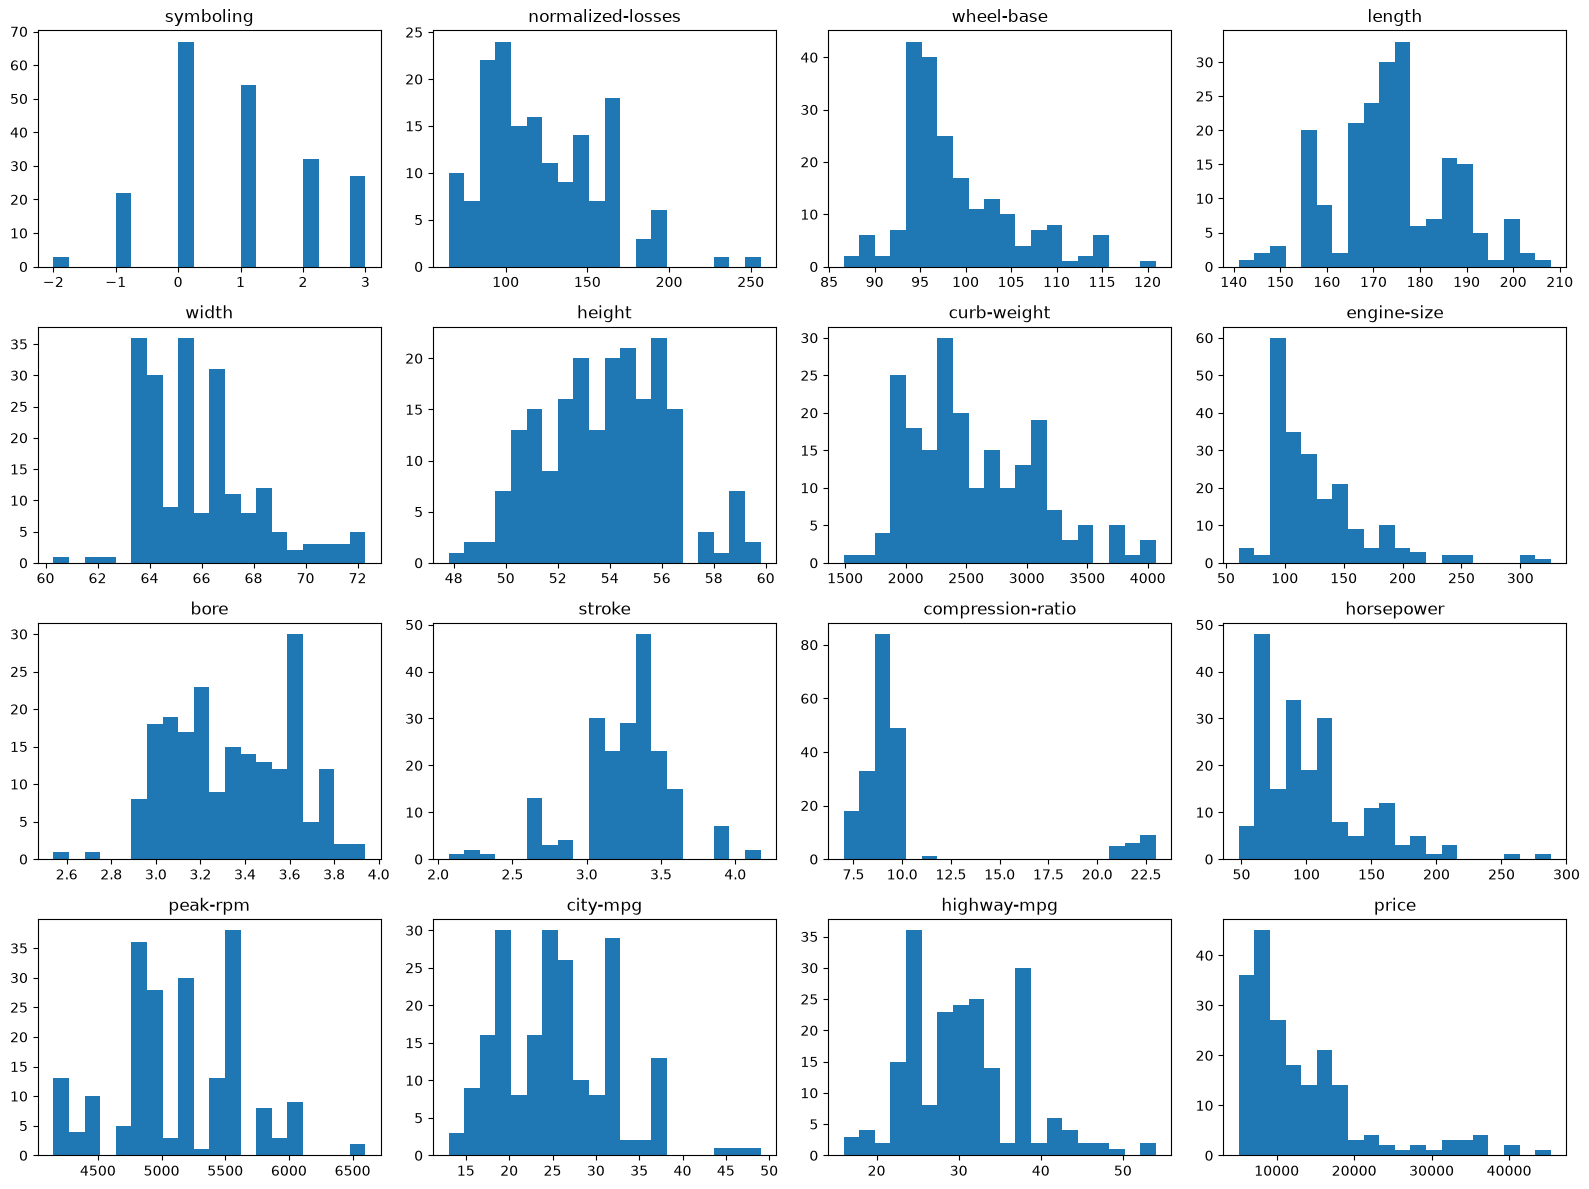

price skew: 1.81


In [3]:
numeric_cols = auto_data.select_dtypes(include="number").columns
n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(auto_data[col].dropna(), bins=20)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# price is strongly right-skewed, which is worth keeping in mind when reading the residuals later
print(f"price skew: {auto_data['price'].skew():.2f}")

### 2: Categorical Data

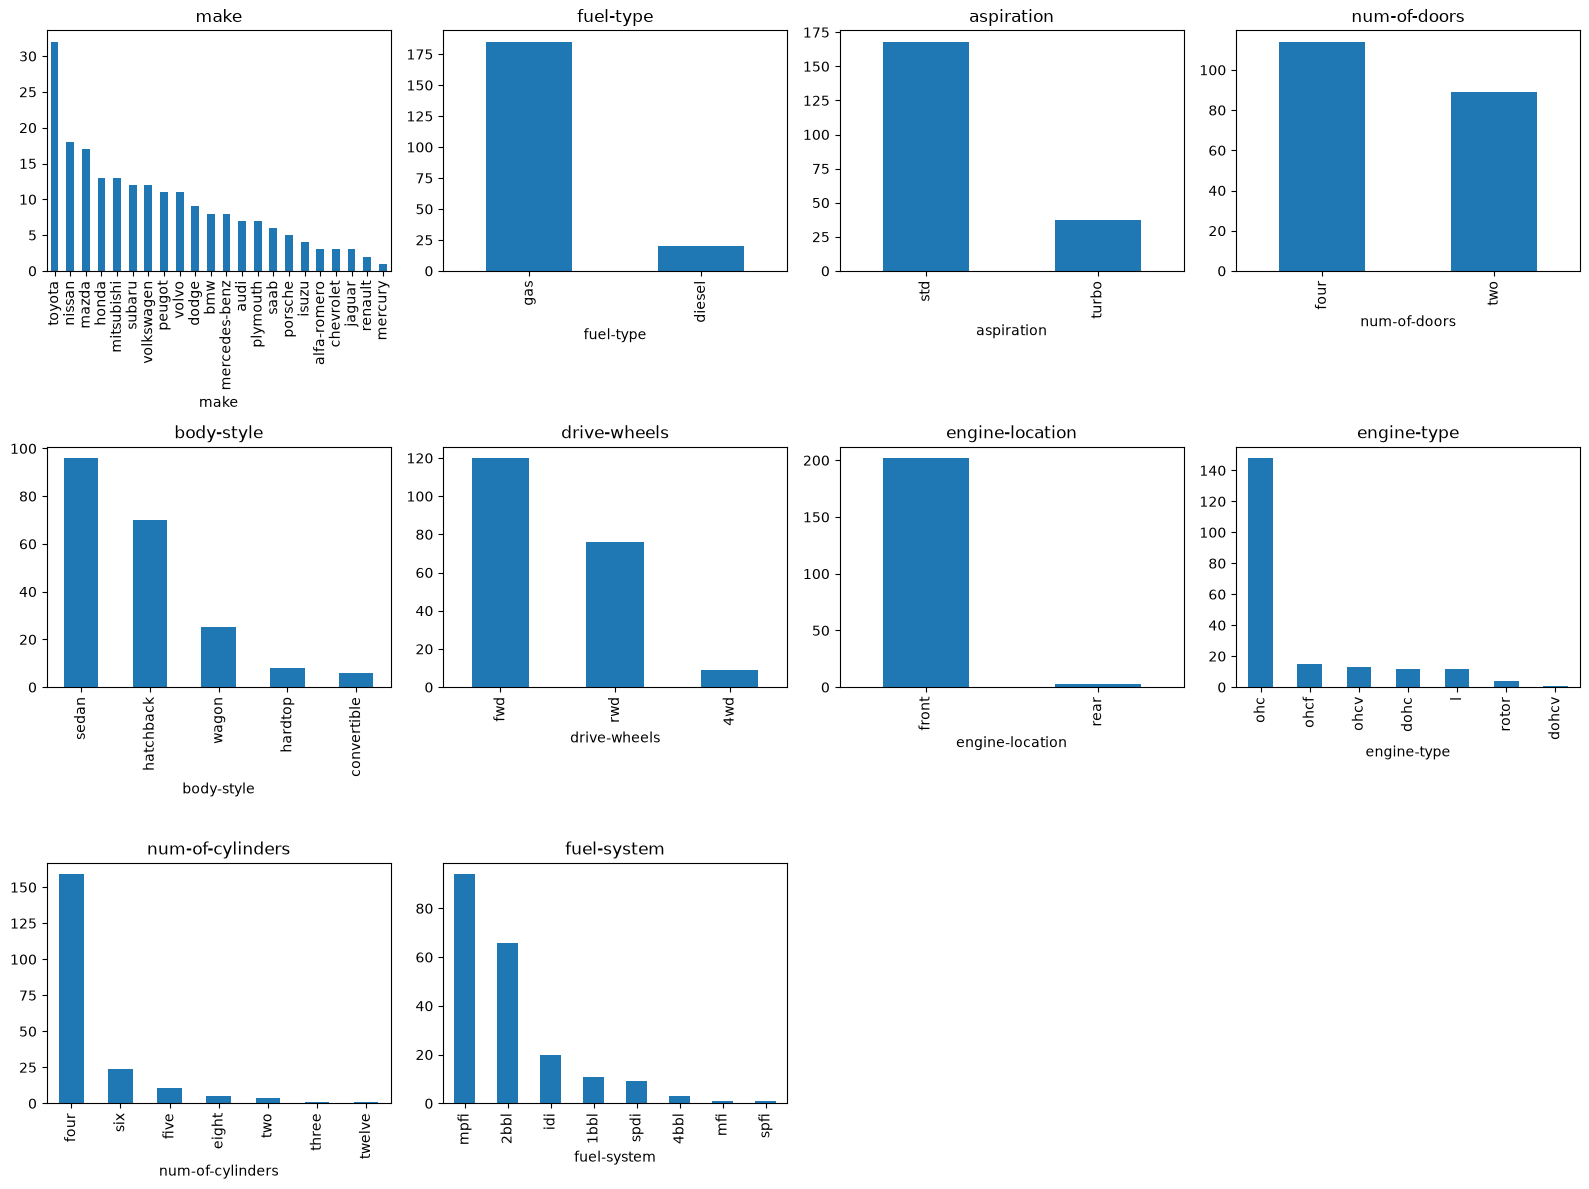

make has 22 distinct categories


In [4]:
cat_cols = auto_data.select_dtypes(include=["object", "string"]).columns

n = len(cat_cols)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    auto_data[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

print(f"make has {auto_data['make'].nunique()} distinct categories")

## Check for Correlations

We now check how strongly each numeric column correlates with price, and then look at the pairwise correlations between the features themselves, since strong correlations *between* predictors are what motivate the regularised models later on.

In [5]:
corr_matrix = auto_data[numeric_cols].corr()

price_corr = corr_matrix["price"]

price_corr_sorted = price_corr.sort_values(ascending=False)

print(price_corr_sorted)

price                1.000000
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810533
width                0.751265
length               0.690628
wheel-base           0.584642
bore                 0.543436
normalized-losses    0.203254
height               0.135486
stroke               0.082310
compression-ratio    0.071107
symboling           -0.082391
peak-rpm            -0.101649
city-mpg            -0.686571
highway-mpg         -0.704692
Name: price, dtype: float64


## Correlation Heatmap

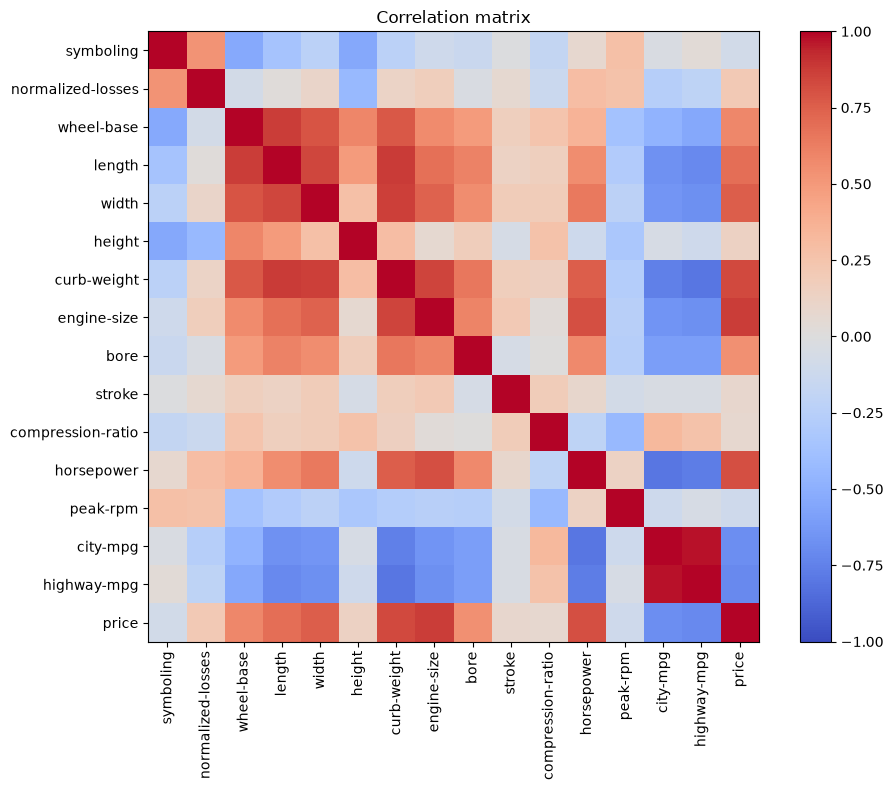

city-mpg     highway-mpg    0.971337
length       curb-weight    0.877728
             wheel-base     0.874587
curb-weight  width          0.867032
engine-size  curb-weight    0.850594
length       width          0.841118
horsepower   engine-size    0.810773
city-mpg     horsepower     0.803620
dtype: float64


In [6]:
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

# the strongest feature-feature pairs, which is what actually motivates Ridge/Lasso
pairs = corr_matrix.drop(index="price", columns="price").abs().unstack()
pairs = pairs[pairs < 1].sort_values(ascending=False)
print(pairs.iloc[::2].head(8))

## Check missing values

In [7]:
for col in auto_data.columns:
    print(f"{col} has {auto_data[col].isna().sum()} missing values")

symboling has 0 missing values
normalized-losses has 41 missing values
make has 0 missing values
fuel-type has 0 missing values
aspiration has 0 missing values
num-of-doors has 2 missing values
body-style has 0 missing values
drive-wheels has 0 missing values
engine-location has 0 missing values
wheel-base has 0 missing values
length has 0 missing values
width has 0 missing values
height has 0 missing values
curb-weight has 0 missing values
engine-type has 0 missing values
num-of-cylinders has 0 missing values
engine-size has 0 missing values
fuel-system has 0 missing values
bore has 4 missing values
stroke has 4 missing values
compression-ratio has 0 missing values
horsepower has 2 missing values
peak-rpm has 2 missing values
city-mpg has 0 missing values
highway-mpg has 0 missing values
price has 4 missing values


## Evaluate and Change

The `normalized-losses` column is a real constraint here, 41 missing values. I have decided to remove the whole column, since it wouldn't have much predictive power — its correlation with price is only 0.20, and insurance losses plausibly depend on the driver's experience and claim history as much as on the car itself. `num-of-doors` will be converted to a numerical column, since 2 and 4 doors are integers. Rows with a missing price are removed completely: the target can't be imputed without inventing the very quantity the model is supposed to learn, and a row with no label contributes nothing to fitting anyway.

One caveat on the two decisions above and on the price threshold in the next section: they were all made while looking at the full dataset, before the split. That is mild peeking. It is a judgement call at this sample size, but a stricter version of this notebook would split first and inspect only the training half.

In [8]:
door_map = {"two": 2, "four": 4}
auto_data["num-of-doors"] = auto_data["num-of-doors"].map(door_map)

auto_data = auto_data.drop(columns=["normalized-losses"])

auto_data = auto_data.dropna(subset=["price"])

print(f"{len(auto_data)} rows remaining")

201 rows remaining


## Train Test Split

We use stratified sampling to better represent groups inside the population (cars). With only ~200 rows, a plain random split can easily land most of the expensive cars on one side. Let's see how many cars sit below 20000, since above that one would start to consider them "expensive" — the threshold is a judgement call, not something the data picks out.

In [9]:
price_counts = (auto_data["price"] < 20000).value_counts()
print(price_counts)
print(f"\nexpensive share: {(auto_data['price'] >= 20000).mean():.1%}")

price
True     176
False     25
Name: count, dtype: int64

expensive share: 12.4%


Great, about 12.4% of the cars (25 out of 201) fall into the expensive group. Stratifying on this split keeps roughly that proportion in both the training and the test set, so now split the data into two sets: the training and the test set.

In [10]:
price_bin = (auto_data["price"] < 20000)

train_data, test_data = train_test_split(
    auto_data,
    test_size=0.2,
    stratify=price_bin,
    random_state=42
)

train_data = train_data.copy()
test_data = test_data.copy()

print(f"train: {len(train_data)} rows, test: {len(test_data)} rows")

train: 160 rows, test: 41 rows


## Impute missing data

For missing values in `num-of-doors` use a mode imputer, since values cannot be anything other than 2 or 4 (unless you have a 3 door car, which might be a little bit of an inconvenience!). As for everything else, we use the mean, simple but effective — and with only 2–4 missing entries in each of `bore`, `stroke`, `horsepower` and `peak-rpm`, the choice of imputer can barely move the results. Both imputers are fitted on the training set only and then applied to the test set, so no information from the test set leaks into the fitted values.

In [11]:
mean_imputer = SimpleImputer(strategy="mean")
mode_imputer = SimpleImputer(strategy="most_frequent")

mean_cols = ["bore", "stroke", "horsepower", "peak-rpm"]
mode_cols = ["num-of-doors"]

train_data[mean_cols] = mean_imputer.fit_transform(train_data[mean_cols])
test_data[mean_cols] = mean_imputer.transform(test_data[mean_cols])

train_data[mode_cols] = mode_imputer.fit_transform(train_data[mode_cols])
test_data[mode_cols] = mode_imputer.transform(test_data[mode_cols])

## Encode Categorical data

For values in `cylinder_order`, `OrdinalEncoder` can be used, since the categories have a genuine ordering (two < three < four < ...) and mapping them to a single number keeps the feature count down. Everything else is one-hot encoded, except `make`, which has too many categories, so frequency encoding is used instead.

That last one requires a little bit of explanation. The drawback is that frequency encoding compresses every make down to how often it appears in the training set, so two makes with a similar number of cars get a near-identical code regardless of price — a rare expensive make and a rare cheap make become indistinguishable to the model, and the encoding effectively imposes an ordering by market share, which has nothing to do with price. A make that only appears in the test set is mapped to 0, i.e. placed outside the range the model was trained on. Every other option I considered has a bigger drawback at this sample size: one-hot on 22 makes would add 22 columns to a 160-row training set, and target encoding would need its own inner cross-validation to avoid leaking price into the feature.

In [12]:
cylinder_order = ["two", "three", "four", "five", "six", "eight", "twelve"]
ordinal_encoder = OrdinalEncoder(categories=[cylinder_order])

train_data["num-of-cylinders"] = ordinal_encoder.fit_transform(train_data[["num-of-cylinders"]])
test_data["num-of-cylinders"] = ordinal_encoder.transform(test_data[["num-of-cylinders"]])

make_freq = train_data["make"].value_counts(normalize=True)

train_data["make"] = train_data["make"].map(make_freq)
test_data["make"] = test_data["make"].map(make_freq).fillna(0)

onehot_cols = ["fuel-type", "aspiration", "body-style", "drive-wheels",
               "engine-location", "fuel-system", "engine-type"]

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

train_encoded = onehot_encoder.fit_transform(train_data[onehot_cols])
test_encoded = onehot_encoder.transform(test_data[onehot_cols])

train_encoded_df = pd.DataFrame(train_encoded, columns=onehot_encoder.get_feature_names_out(onehot_cols), index=train_data.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=onehot_encoder.get_feature_names_out(onehot_cols), index=test_data.index)

train_data = pd.concat([train_data.drop(columns=onehot_cols), train_encoded_df], axis=1)
test_data = pd.concat([test_data.drop(columns=onehot_cols), test_encoded_df], axis=1)

## Feature Scaling

Ridge and Lasso require feature scaling, because their penalty terms penalise the absolute size of the coefficients, meaning unscaled features with larger numeric units will be unfairly and unevenly penalised. This applies to the ordinal columns (`symboling`, `num-of-doors`, `num-of-cylinders`) as well as the continuous ones — leaving them out would put them on a different footing to everything else under the penalty. The one-hot columns are deliberately left as 0/1: they are already on a common scale, and standardising them would inflate the coefficient of a rare category.

In [13]:
numeric_cols_to_scale = ["wheel-base", "length", "width", "height", "curb-weight",
                         "engine-size", "bore", "stroke", "compression-ratio",
                         "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "make",
                         "symboling", "num-of-doors", "num-of-cylinders"]

scaler = StandardScaler()

train_data[numeric_cols_to_scale] = scaler.fit_transform(train_data[numeric_cols_to_scale])
test_data[numeric_cols_to_scale] = scaler.transform(test_data[numeric_cols_to_scale])

In [14]:
feature_cols = [col for col in train_data.columns if col != "price"]

X_train = train_data[feature_cols]
y_train = train_data["price"]
X_test = test_data[feature_cols]
y_test = test_data["price"]

# nothing should be missing by this point, and train/test must agree on columns
assert X_train.isna().sum().sum() == 0, "missing values left in X_train"
assert X_test.isna().sum().sum() == 0, "missing values left in X_test"
assert list(X_train.columns) == list(X_test.columns), "column mismatch between train and test"
print(f"{X_train.shape[1]} features, {X_train.shape[0]} training rows")

44 features, 160 training rows


## Fit and Evaluate the model

Three penalised models are compared against plain OLS as a baseline, with the penalty strength α chosen by cross-validation on the training set. `RidgeCV()` with no arguments only searches α ∈ {0.1, 1, 10}, so the grid is passed explicitly to give the penalty a real range to move over. ElasticNet is included to sit between the two penalties, with the L1/L2 mix also chosen by cross-validation.

Training RMSE is reported alongside test RMSE: without it there is no way to tell whether OLS is overfitting, which is exactly the question the Ridge comparison is asking.

In [15]:
alphas = np.logspace(-3, 3, 100)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": RidgeCV(alphas=alphas),
    "Lasso": LassoCV(max_iter=200_000, cv=5, random_state=42),
    "ElasticNet": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
                               max_iter=200_000, cv=5, random_state=42),
}

rows = []
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    rows.append({
        "Model": name,
        "Best alpha": getattr(model, "alpha_", "-"),
        "Train RMSE": root_mean_squared_error(y_train, train_pred),
        "Test RMSE": root_mean_squared_error(y_test, test_pred),
        "Test R2": r2_score(y_test, test_pred),
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

            Model  Best alpha  Train RMSE   Test RMSE  Test R2
Linear Regression           - 2118.611366 2324.353974 0.912039
            Ridge    1.417474 2270.007765 2464.467548 0.901115
            Lasso  183.035551 2977.902980 3295.624736 0.823169
       ElasticNet   16.080302 2855.906984 3060.679915 0.847483


### How much of that gap is real?

A single 41-row test set cannot separate models whose RMSE differs by a few percent. Below the same models are scored with repeated 5-fold cross-validation on the training set (10 repeats, so 50 fits each), which gives a spread as well as a mean.

One honest caveat: the imputer, encoders and scaler were fitted on the whole training set before this loop, so a small amount of information crosses fold boundaries and the absolute scores are mildly optimistic. The *comparison* between models is still fair, since all four share identical preprocessing. Rebuilding the preprocessing as a `Pipeline` inside the cross-validation is the correct fix and the natural next version of this notebook.

In [16]:
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_rows = []
for name, model in models.items():
    scores = -cross_val_score(model, X_train, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error")
    cv_rows.append({
        "Model": name,
        "CV RMSE mean": scores.mean(),
        "CV RMSE std": scores.std(),
        "95% range": f"{scores.mean() - 2 * scores.std():.0f} – {scores.mean() + 2 * scores.std():.0f}",
    })

cv_results = pd.DataFrame(cv_rows)
print(cv_results.to_string(index=False))

            Model  CV RMSE mean  CV RMSE std   95% range
Linear Regression   3301.135018   764.389516 1772 – 4830
            Ridge   3374.754941   697.430948 1980 – 4770
            Lasso   3449.537446   712.168006 2025 – 4874
       ElasticNet   3389.169122   703.037372 1983 – 4795


### What Lasso kept

The score is not the interesting output of a Lasso fit — the selection is. Below are the coefficients it did not drive to zero, which is a readable summary of which features carry the price signal once the correlated ones are forced to compete.

In [17]:
lasso_coefs = pd.Series(fitted["Lasso"].coef_, index=X_train.columns)
kept = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)

print(f"Lasso kept {len(kept)} of {len(lasso_coefs)} features\n")
print(kept.to_string())

Lasso kept 13 of 44 features

engine-size          3570.117527
horsepower           1777.521372
drive-wheels_rwd     1424.011954
make                -1061.985720
width                1048.700451
compression-ratio     564.288143
height                344.451032
drive-wheels_fwd     -328.816137
highway-mpg          -181.416757
peak-rpm              161.755417
stroke               -143.643033
curb-weight           110.517453
num-of-cylinders       65.014858


### Residuals

Predicted against actual, and residuals against fitted value. The second plot is the one to read: if the spread widens as the fitted price rises, the constant-variance assumption behind OLS is failing and a log-transformed target would be the fix.

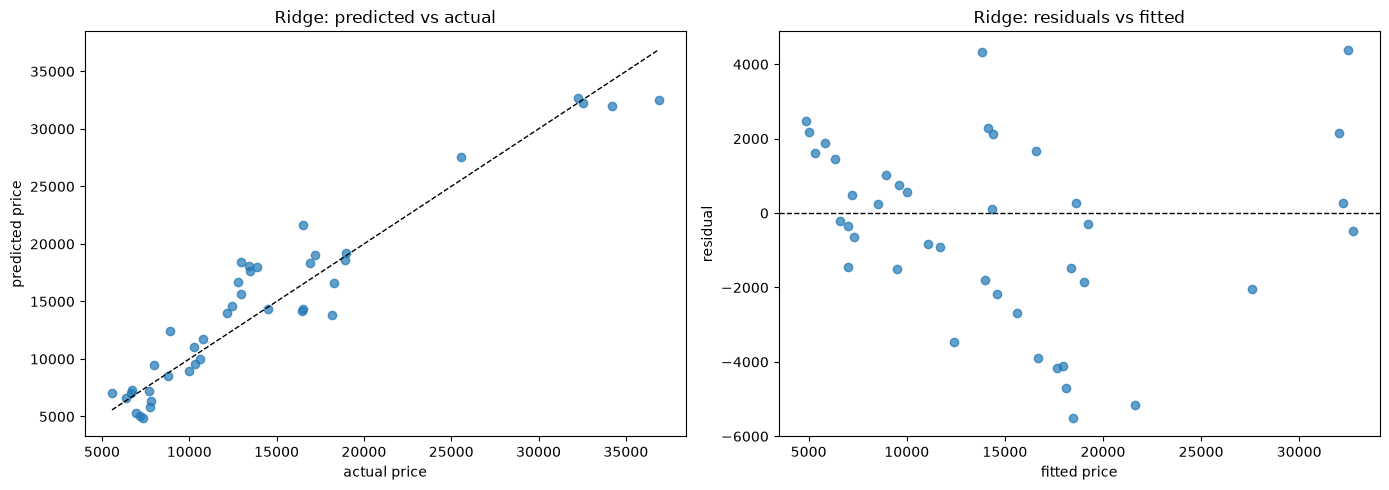

In [18]:
best_name = "Ridge"
best_pred = fitted[best_name].predict(X_test)
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_pred, alpha=0.7)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("actual price")
axes[0].set_ylabel("predicted price")
axes[0].set_title(f"{best_name}: predicted vs actual")

axes[1].scatter(best_pred, residuals, alpha=0.7)
axes[1].axhline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("fitted price")
axes[1].set_ylabel("residual")
axes[1].set_title(f"{best_name}: residuals vs fitted")

plt.tight_layout()
plt.show()

## Result

What was most surprising is that Ridge performed a little bit worse than regular OLS on the held-out set. I was expecting multicollinearity between the car features to hurt OLS, since the heatmap shows a lot of strong positive and negative correlations between distinct features — curb-weight, length, width and wheel-base all move together, and city-mpg against highway-mpg is very close to 1.

Three things make me reluctant to read much into the gap:

1. The test set is 41 cars. The repeated cross-validation above gives a standard deviation across folds that is larger than the difference between the models, so this single split cannot separate them. Whatever ordering the test-set table shows is mostly the seed talking.
2. Ridge with the default `RidgeCV()` grid selected α = 1.0, which on standardised features shrinks almost nothing — so "Ridge ≈ OLS" under that grid was close to a tautology rather than evidence against regularisation. Widening the grid to `logspace(-3, 3, 100)` is what makes the comparison meaningful at all.
3. Multicollinearity inflates the *variance* of the OLS coefficients but leaves them unbiased. With a fairly strong signal (R² ≈ 0.9) and around 45 features against 160 training rows, the variance penalty may simply not be large enough to dominate the bias that Ridge introduces in exchange. Regularisation earns its keep when p approaches or exceeds n, and that is not quite the regime here.

Lasso is the harsher of the two penalties on this data, and the useful output is the surviving coefficient list rather than the score — engine-size, curb-weight and horsepower doing most of the work is consistent with the correlation ranking from the start of the notebook.

Next steps: rebuild the preprocessing as a `ColumnTransformer` + `Pipeline` so the cross-validation scores are honest end to end, and model `log(price)` instead of `price`, since price is strongly right-skewed and the residual plot above is the test of whether that matters.